In [34]:
import os
import glob
import math
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
files = glob.glob(os.path.join('../../../Data Collection/data', "*.json"))
df = pd.concat([pd.read_json(f)[1:] for f in files], ignore_index=True)
print(f'Total videos: {len(df)}')

Total videos: 415517


In [3]:
topic_df = pd.read_csv("output/bertopic/topic_documents.csv")
topic_df.shape

(48729, 3)

In [10]:
merged_df = df.merge(
    topic_df[["id", "topic"]],
    on="id",
    how="inner"
)
df.shape, merged_df.shape

((415517, 17), (48844, 18))

In [11]:
# Convert both timestamps to UTC
merged_df["fetched_at"] = pd.to_datetime(merged_df["fetched_at"], utc=True)

merged_df["publishedAt"] = pd.to_datetime(
    merged_df["snippet"].apply(lambda x: x["publishedAt"]),
    utc=True
)

# Calculate age (days)
merged_df["age"] = (merged_df["fetched_at"] - merged_df["publishedAt"]).dt.days

# Extract statistics
merged_df["viewCount"] = merged_df["statistics"].apply(lambda x: int(x.get("viewCount", 0)))
merged_df["likeCount"] = merged_df["statistics"].apply(lambda x: int(x.get("likeCount", 0)))

In [20]:
result = merged_df.apply(
    lambda row: {
        "id": row["id"],
        "topic_id": row["topic"],
        "age": row["age"],
        "viewCount": row["viewCount"],
        "likeCount": row["likeCount"]
    },
    axis=1
).tolist()

len(result)

48844

In [51]:

video = [row for row in result if row['viewCount']>=1000000]
for v in video:
    print(f"{v['viewCount']}, https://www.youtube.com/watch?v={v['id']}")

1775607, https://www.youtube.com/watch?v=ecIWPzGEbFc
8655327, https://www.youtube.com/watch?v=dz7Ntp7KQGA
1271699, https://www.youtube.com/watch?v=y2CnstDLhXM
1129341, https://www.youtube.com/watch?v=kcvEiMFOcoE
1646389, https://www.youtube.com/watch?v=WnMQ8HlmeXc
3410567, https://www.youtube.com/watch?v=ZKOL-rZ79gs
1040216, https://www.youtube.com/watch?v=8eVXTyIZ1Hs
1722724, https://www.youtube.com/watch?v=WjwEh15M5Rw
2102811, https://www.youtube.com/watch?v=rIaz-l1Kf8w
4507324, https://www.youtube.com/watch?v=9TycLR0TqFA
1110494, https://www.youtube.com/watch?v=-E-jfcoR2W0
1878779, https://www.youtube.com/watch?v=-TDh-5n90vk
3726259, https://www.youtube.com/watch?v=4oDLMs11Exs
1017576, https://www.youtube.com/watch?v=gEBMPP0SOnU
1960685, https://www.youtube.com/watch?v=xsxi4qaEnOg
2657979, https://www.youtube.com/watch?v=tv-_1er1mWI
1250454, https://www.youtube.com/watch?v=tAuRQs_d9F8
1507219, https://www.youtube.com/watch?v=NU_1StN5Tkk
1595843, https://www.youtube.com/watch?v=v9ejT

# CDF of ViewCounts

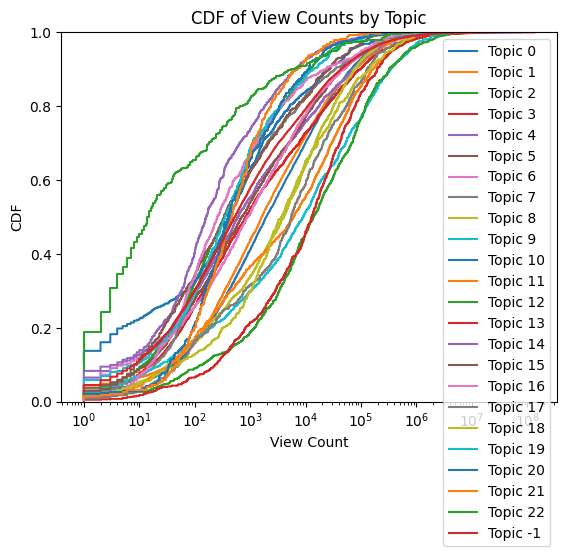

In [46]:
plt.figure()

topic_ids = set(row["topic_id"] for row in result)

for topic_id in topic_ids:
    view_counts = [row["viewCount"] for row in result if row["topic_id"] == topic_id]
    
    sns.ecdfplot(view_counts, log_scale=True, label=f"Topic {topic_id}")

plt.xlabel("View Count")
plt.ylabel("CDF")
plt.title("CDF of View Counts by Topic")
plt.legend()

plt.show()

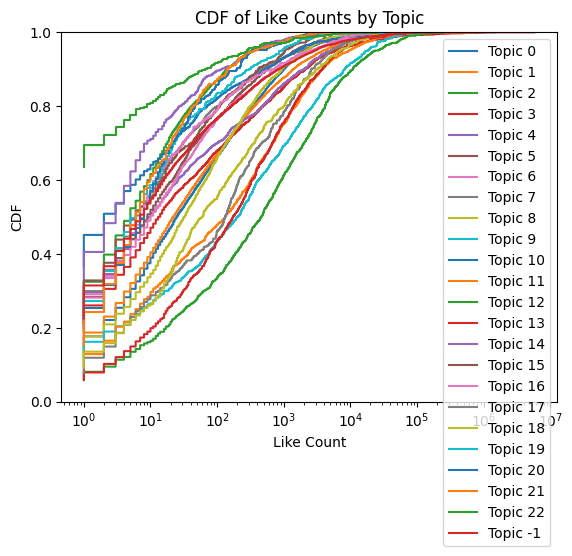

In [52]:
plt.figure()

topic_ids = set(row["topic_id"] for row in result)

for topic_id in topic_ids:
    view_counts = [row["likeCount"] for row in result if row["topic_id"] == topic_id]
    
    sns.ecdfplot(view_counts, log_scale=True, label=f"Topic {topic_id}")

plt.xlabel("Like Count")
plt.ylabel("CDF")
plt.title("CDF of Like Counts by Topic")
plt.legend()

plt.show()

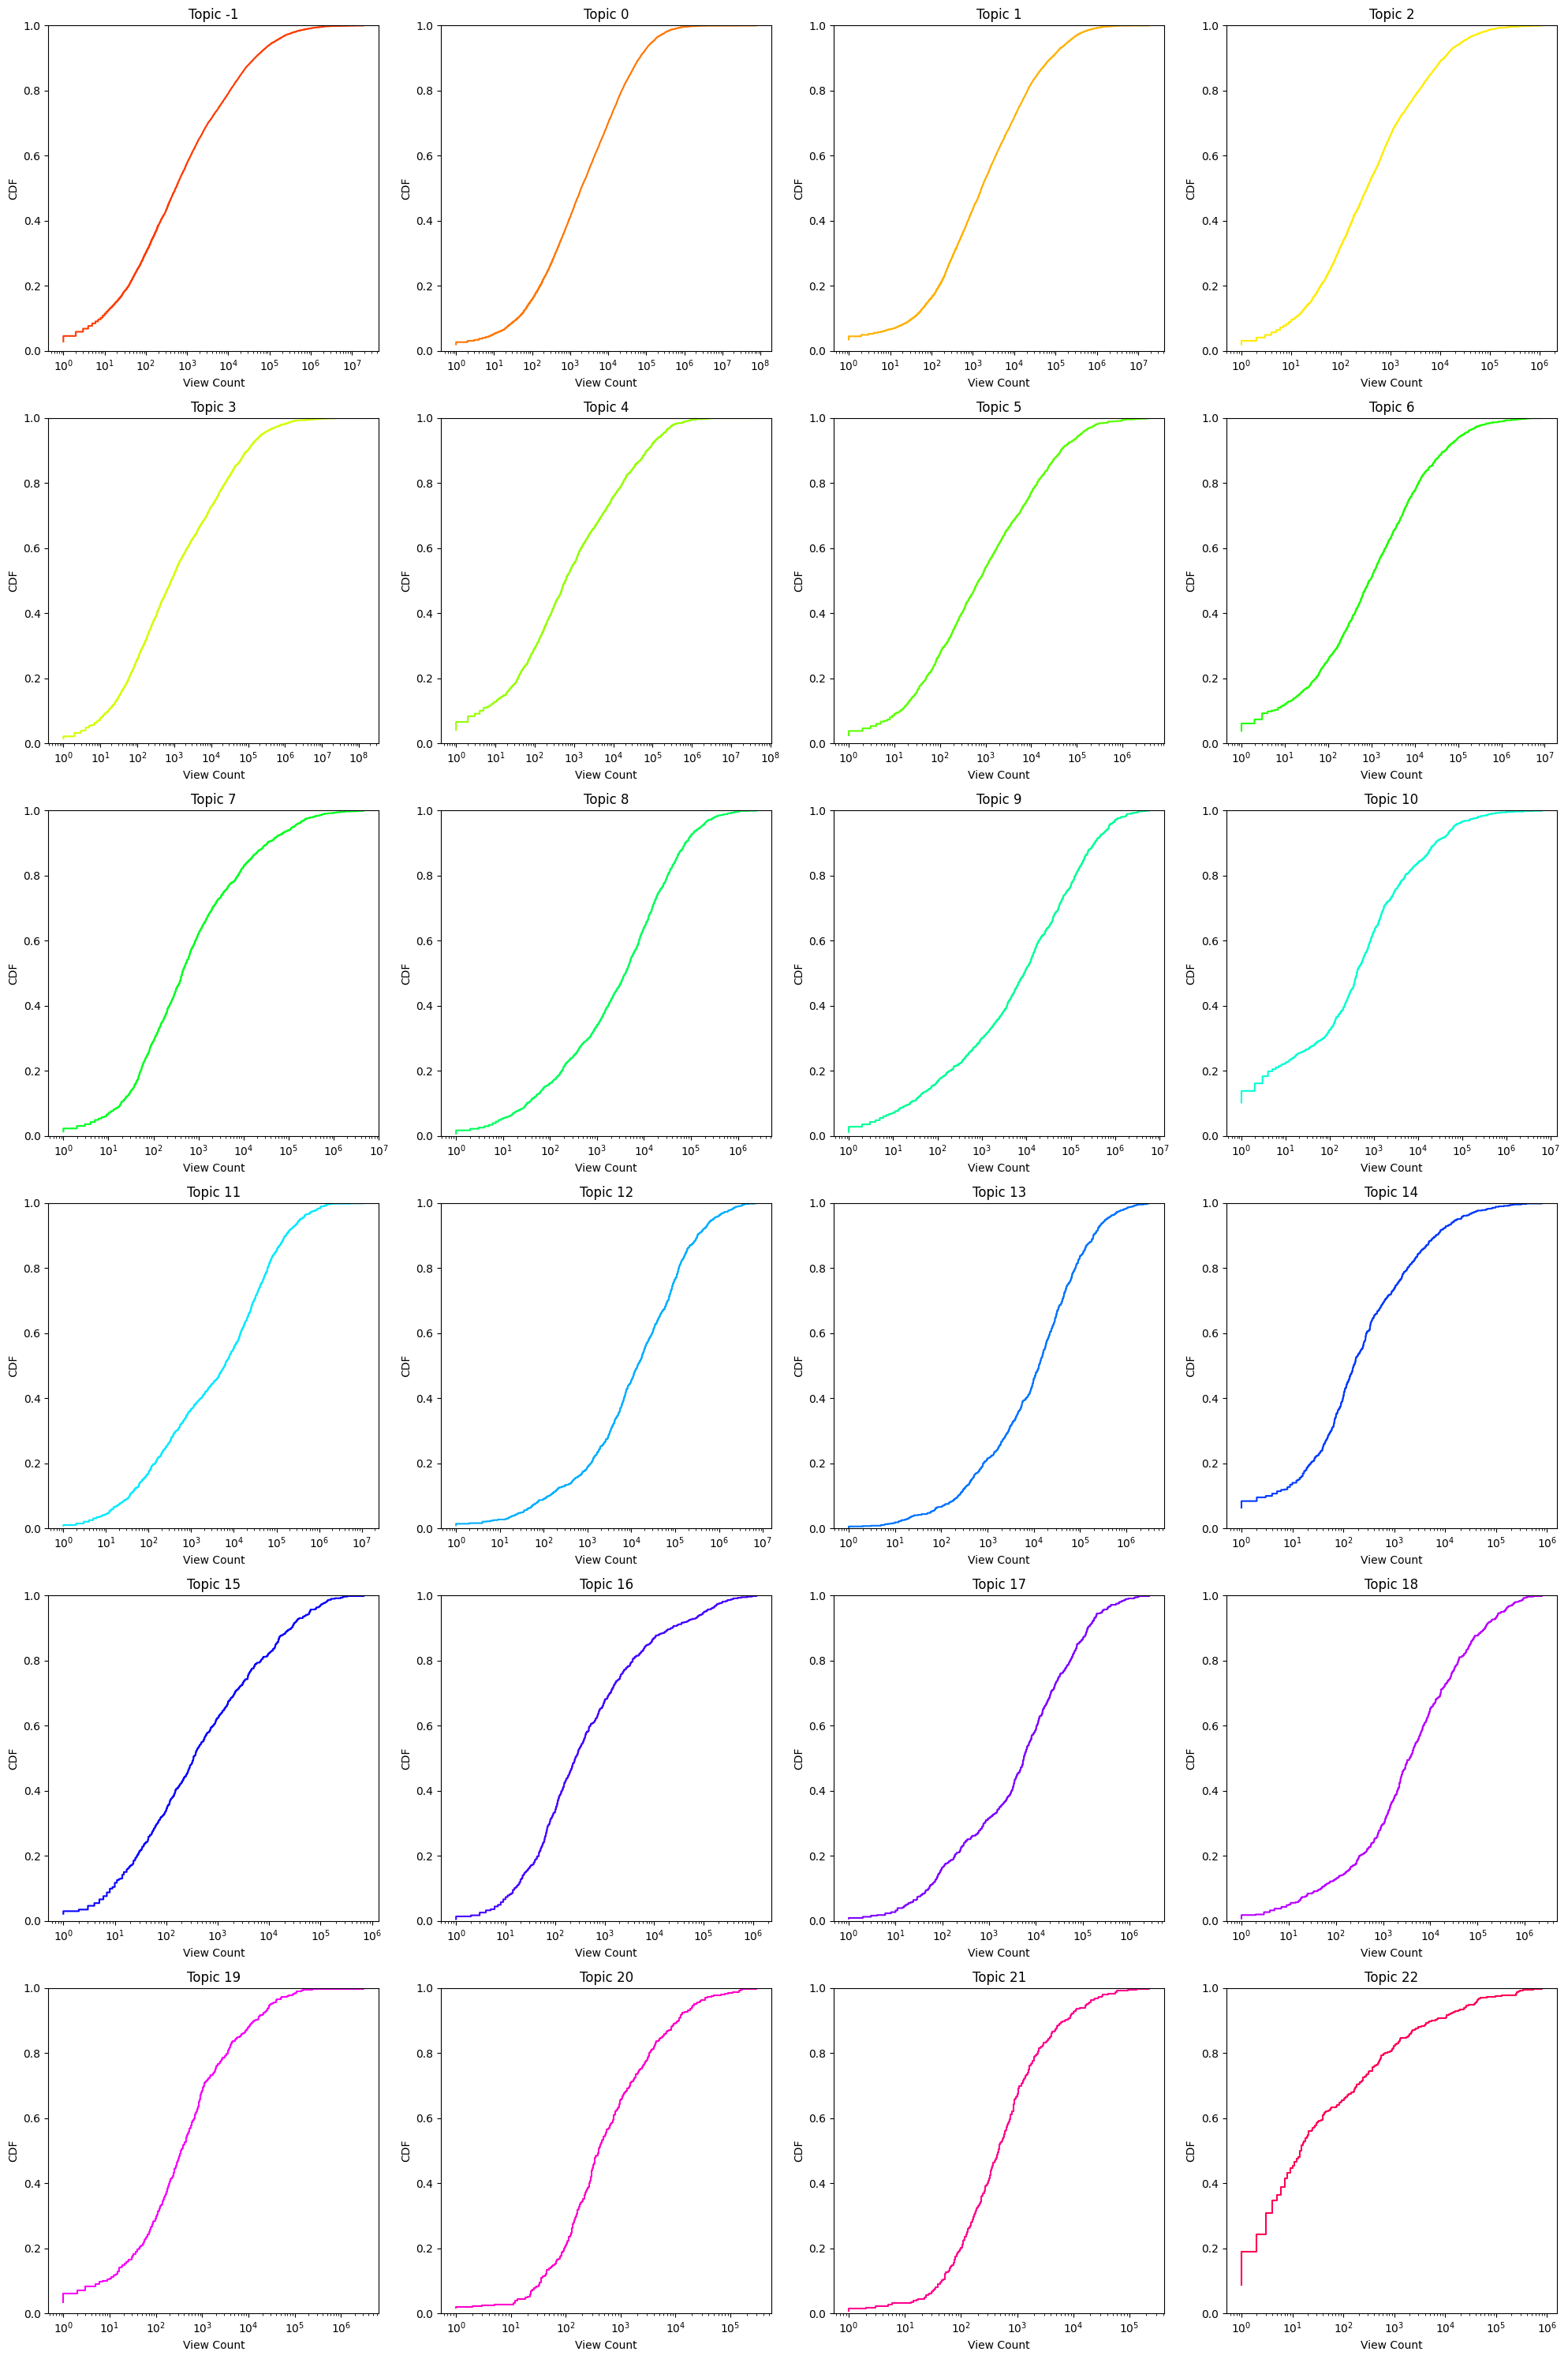

In [40]:
topic_ids = sorted(set(row["topic_id"] for row in result))

cols = 4
rows = math.ceil(len(topic_ids) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, 5*rows))
axes = axes.flatten()

colors = sns.color_palette("hsv", len(topic_ids))

for i, topic_id in enumerate(topic_ids):
    view_counts = [row["viewCount"] for row in result if row["topic_id"] == topic_id]

    sns.ecdfplot(view_counts, log_scale=True, ax=axes[i], color=colors[i])

    axes[i].set_title(f"Topic {topic_id}")
    axes[i].set_xlabel("View Count")
    axes[i].set_ylabel("CDF")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

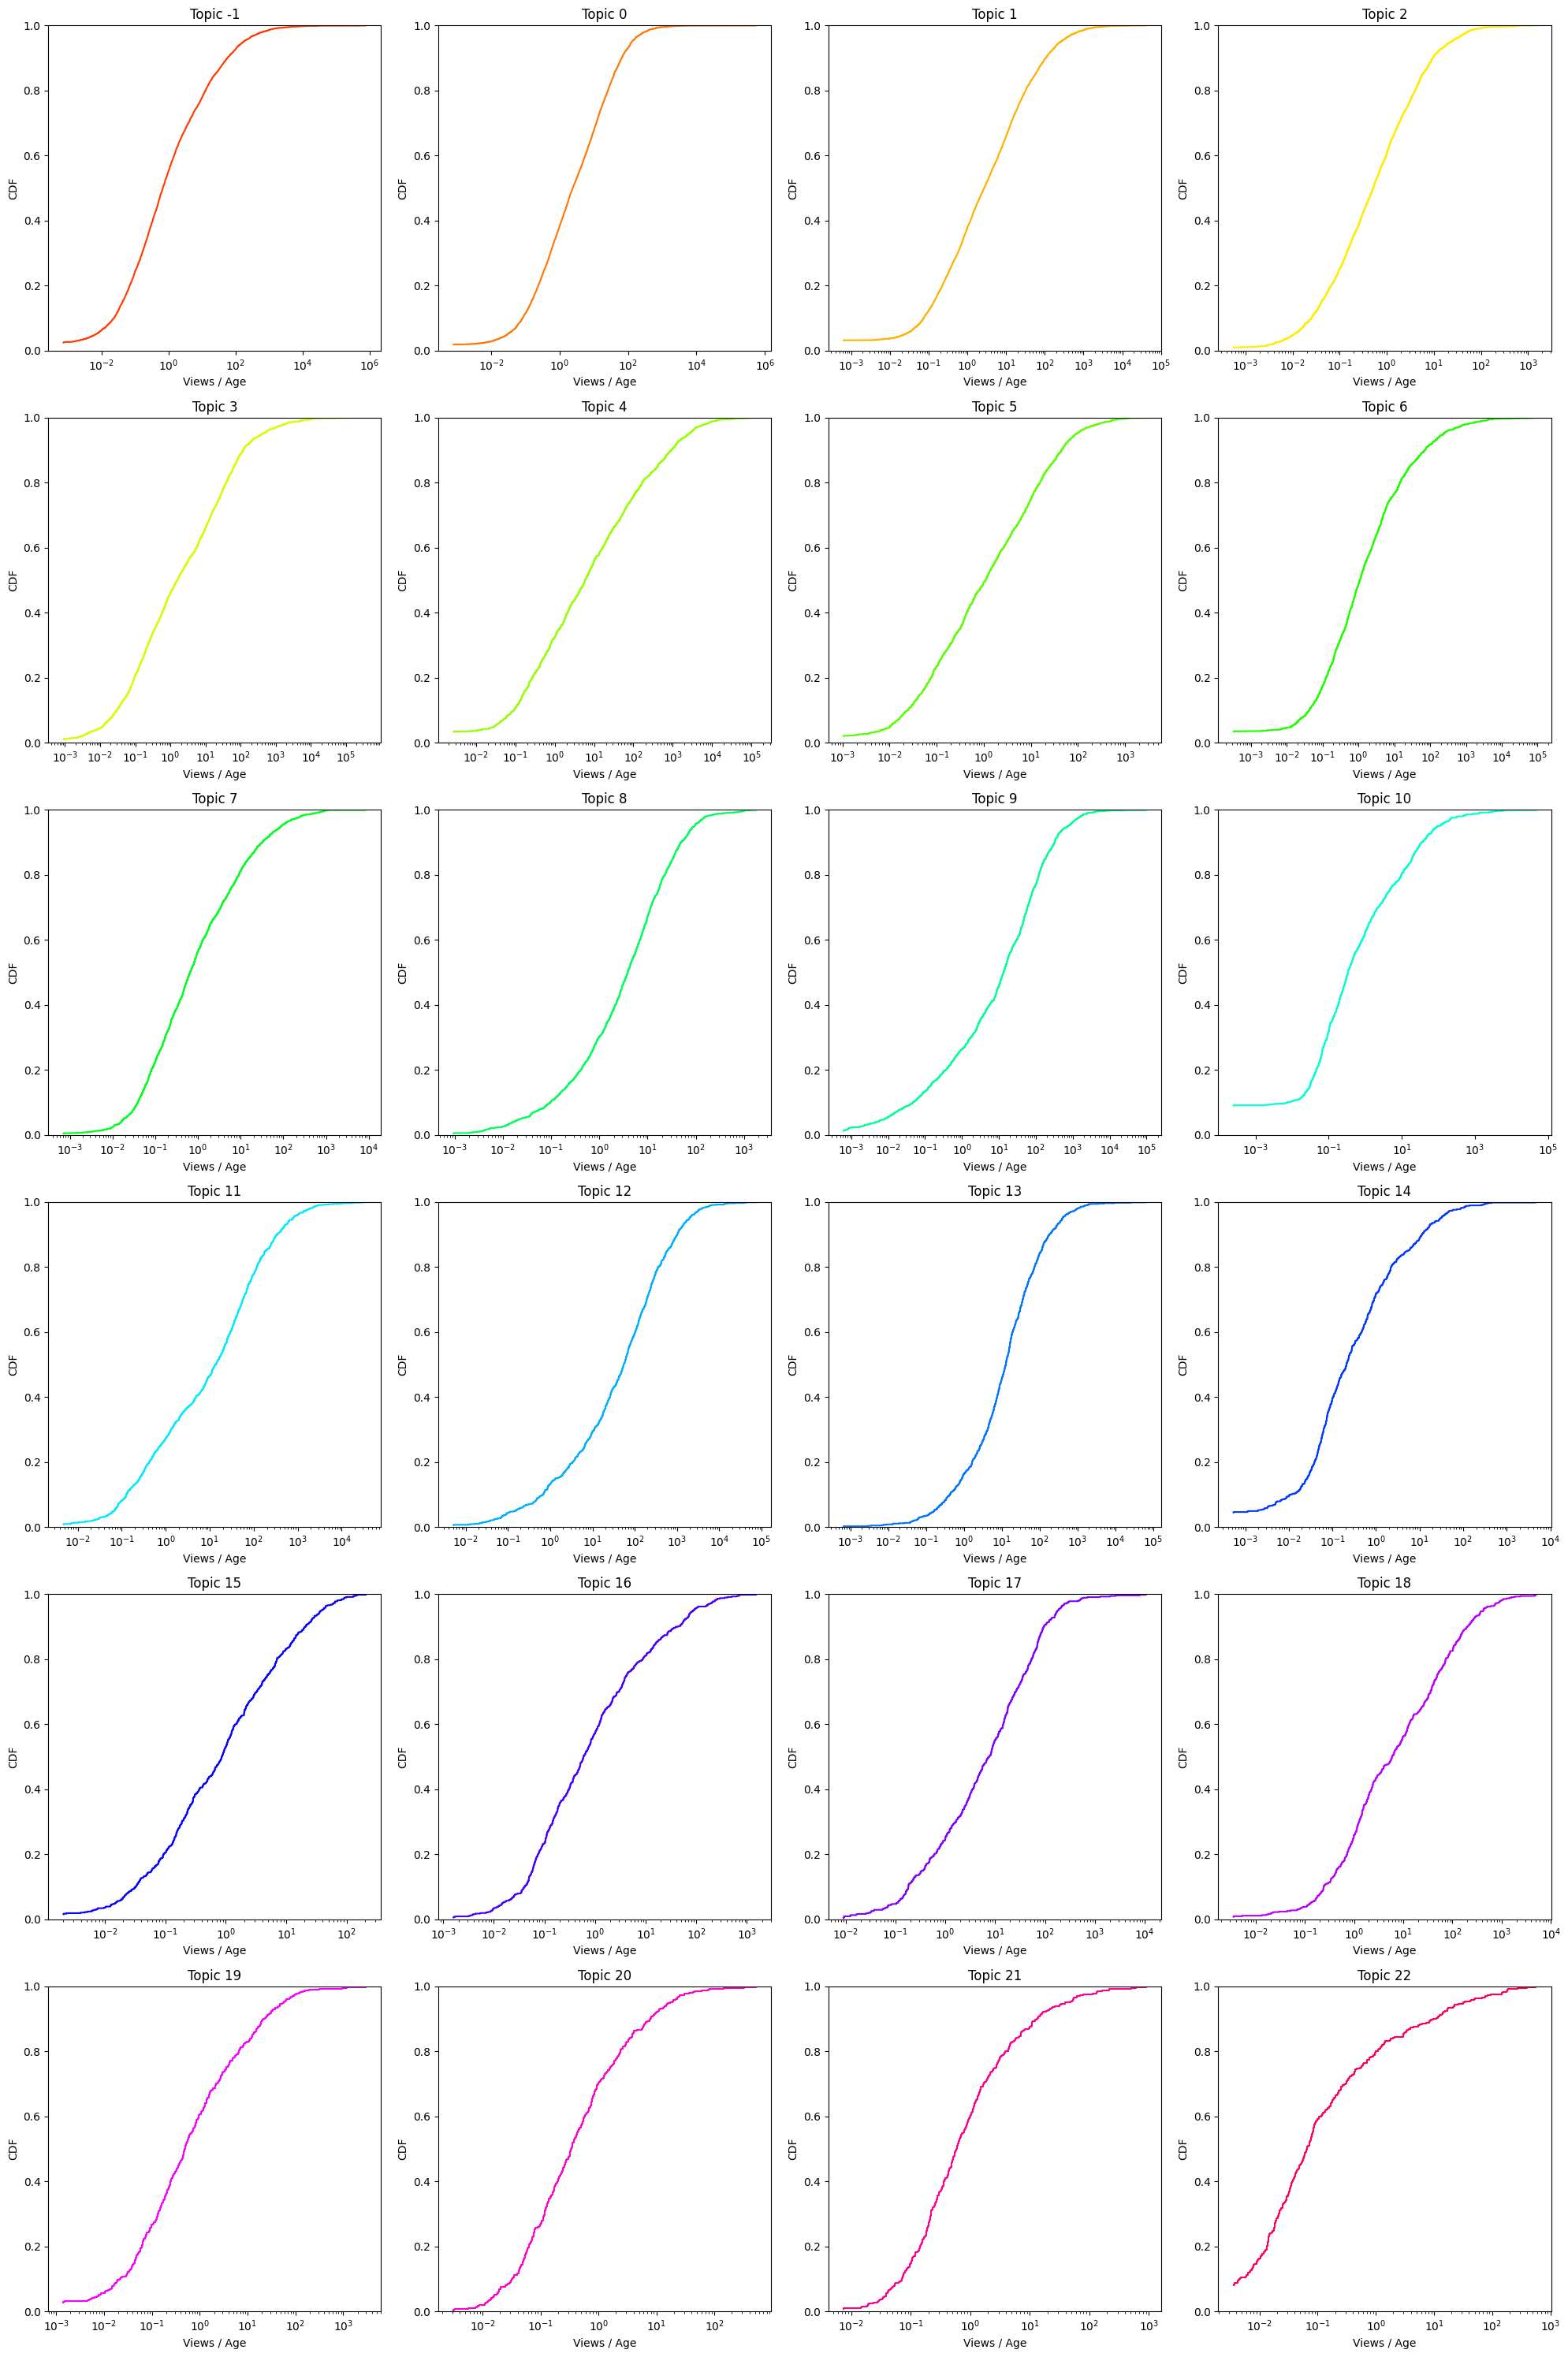

In [ ]:
topic_ids = sorted(set(row["topic_id"] for row in result))

cols = 4
rows = math.ceil(len(topic_ids) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, 5*rows))
axes = axes.flatten()

colors = sns.color_palette("hsv", len(topic_ids))

for i, topic_id in enumerate(topic_ids):
    normalized_views = [
        row["viewCount"] / row["age"]
        for row in result
        if row["topic_id"] == topic_id and row["age"] > 0
    ]

    sns.ecdfplot(normalized_views, log_scale=True, ax=axes[i], color=colors[i])

    axes[i].set_title(f"Topic {topic_id}")
    axes[i].set_xlabel("Views / Age")
    axes[i].set_ylabel("CDF")
modeling techniques in SDP
Topic-modeling techniques have pr
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# CDF of LikeCounts

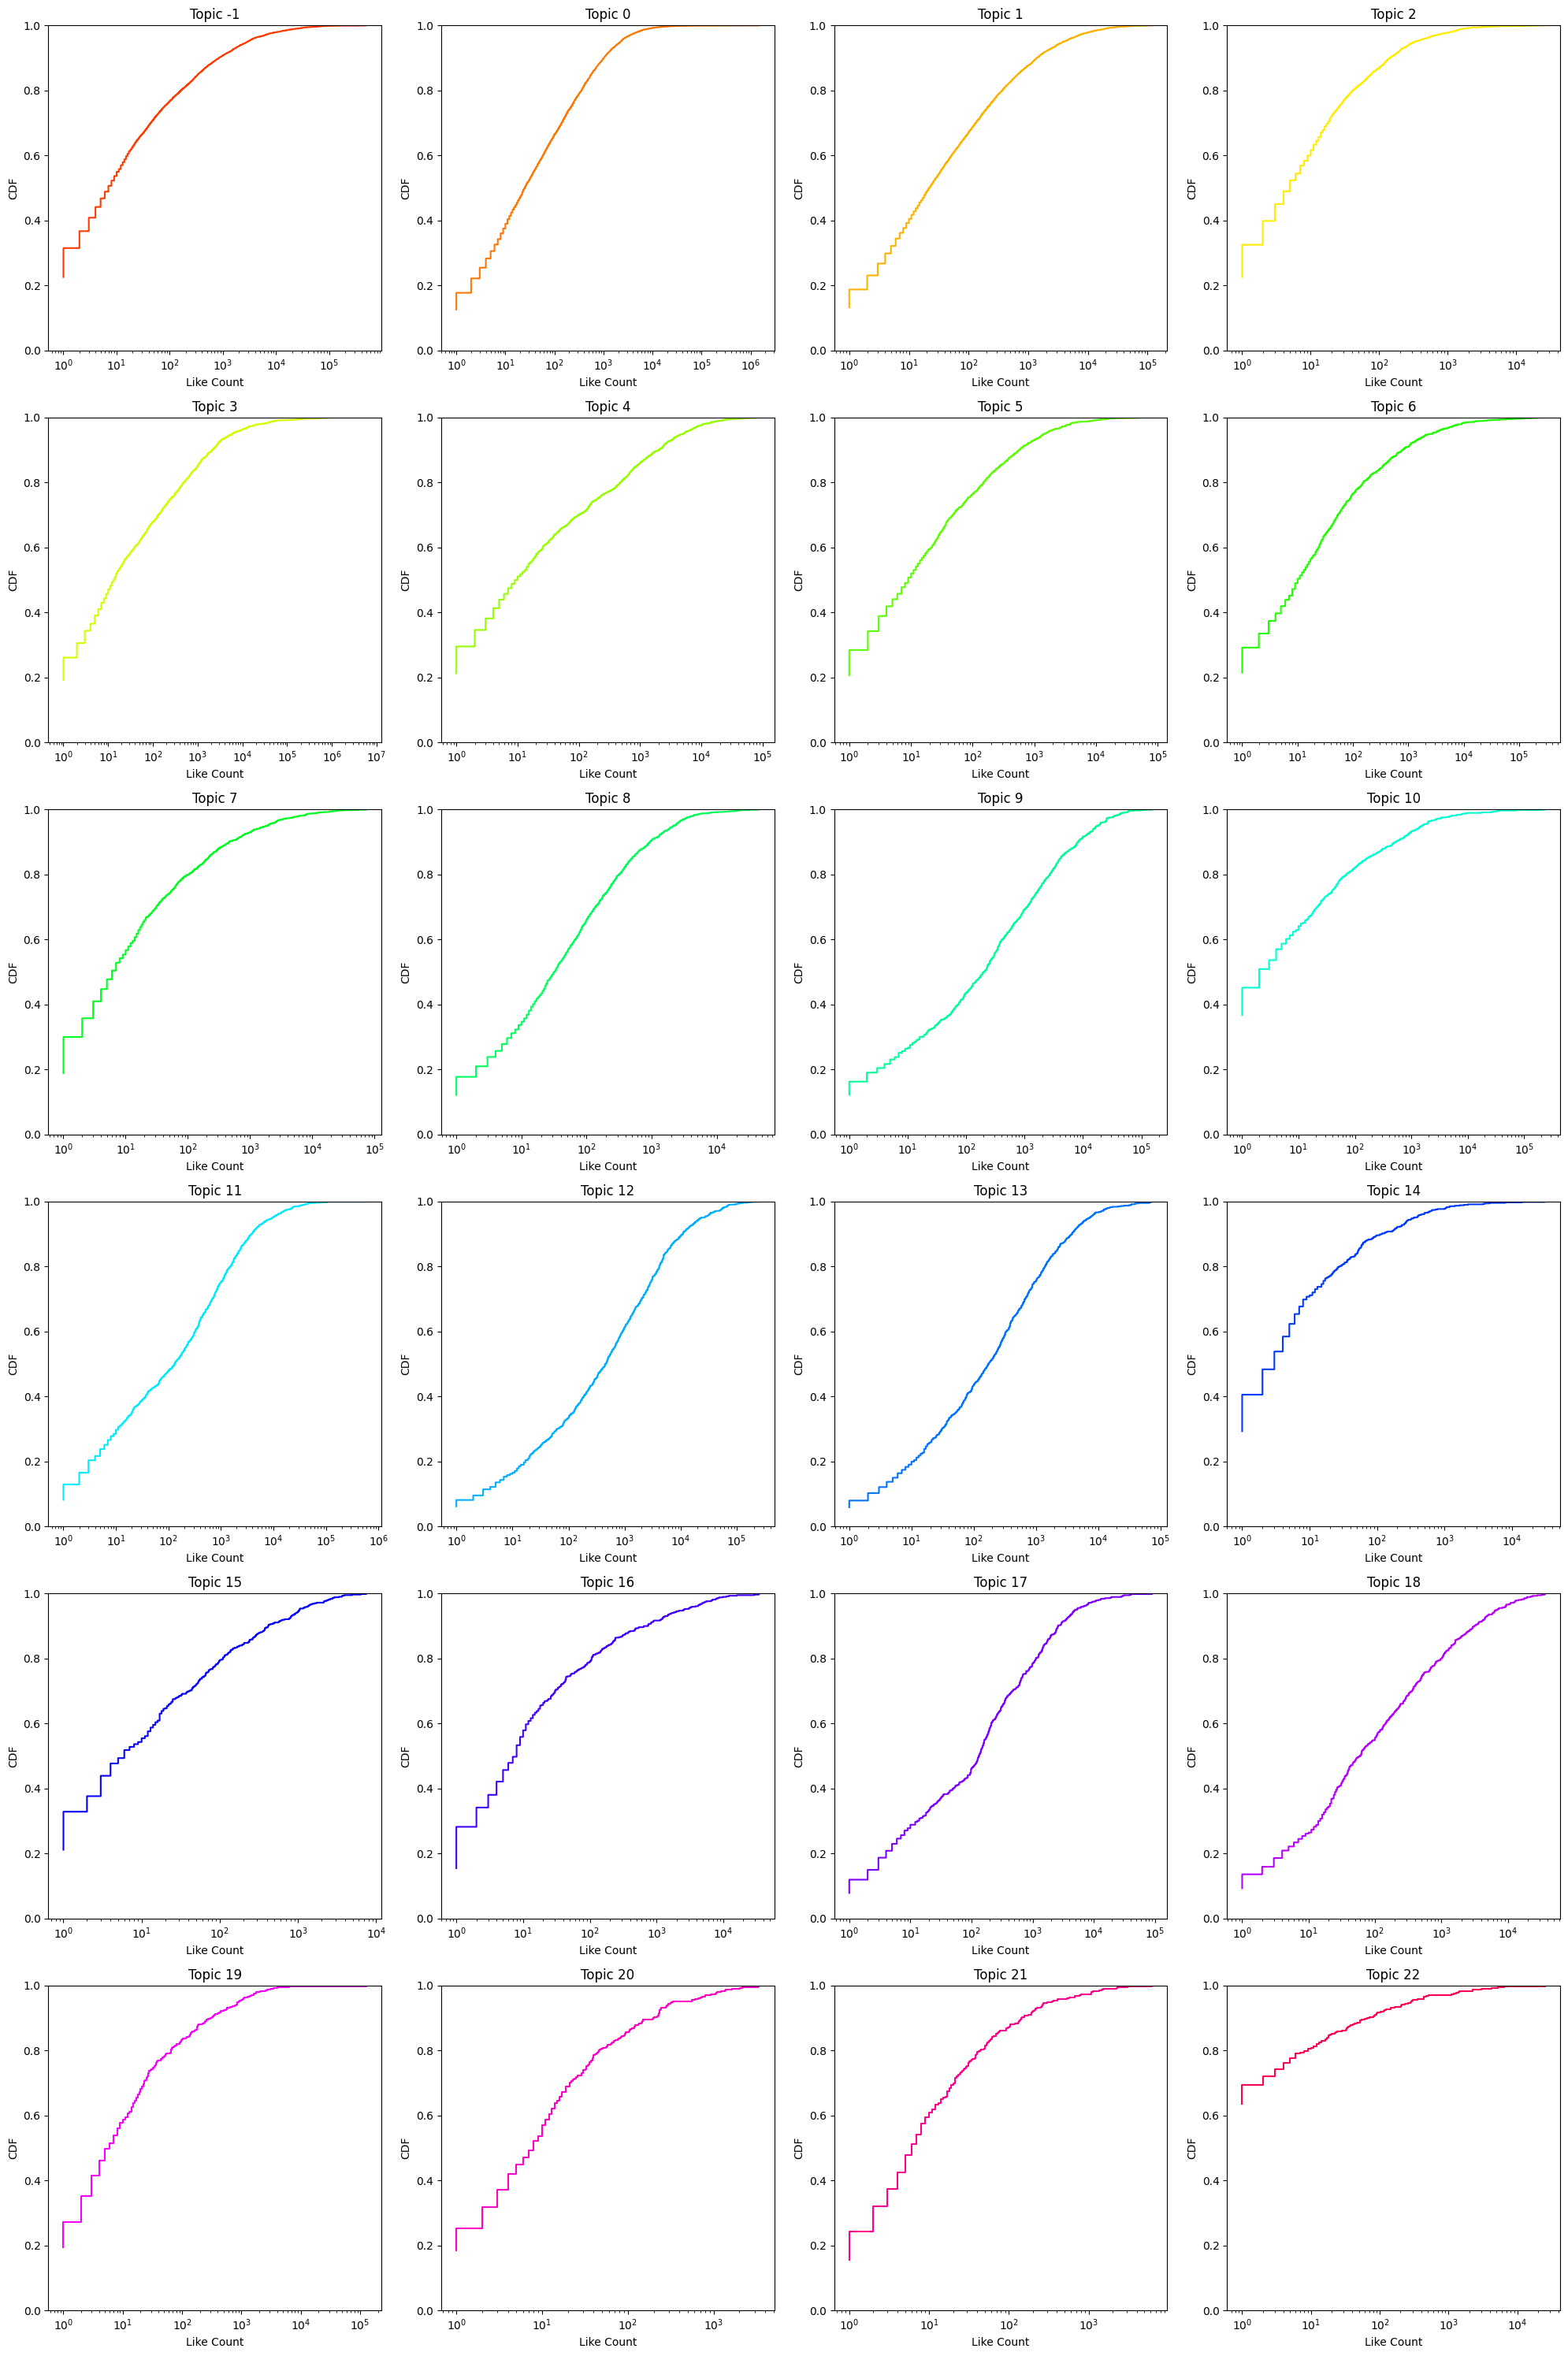

In [38]:
topic_ids = sorted(set(row["topic_id"] for row in result))

cols = 4
rows = math.ceil(len(topic_ids) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, 5*rows))
axes = axes.flatten()

colors = sns.color_palette("hsv", len(topic_ids))

for i, topic_id in enumerate(topic_ids):
    view_counts = [row["likeCount"] for row in result if row["topic_id"] == topic_id]

    sns.ecdfplot(view_counts, log_scale=True, ax=axes[i], color=colors[i])

    axes[i].set_title(f"Topic {topic_id}")
    axes[i].set_xlabel("Like Count")
    axes[i].set_ylabel("CDF")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

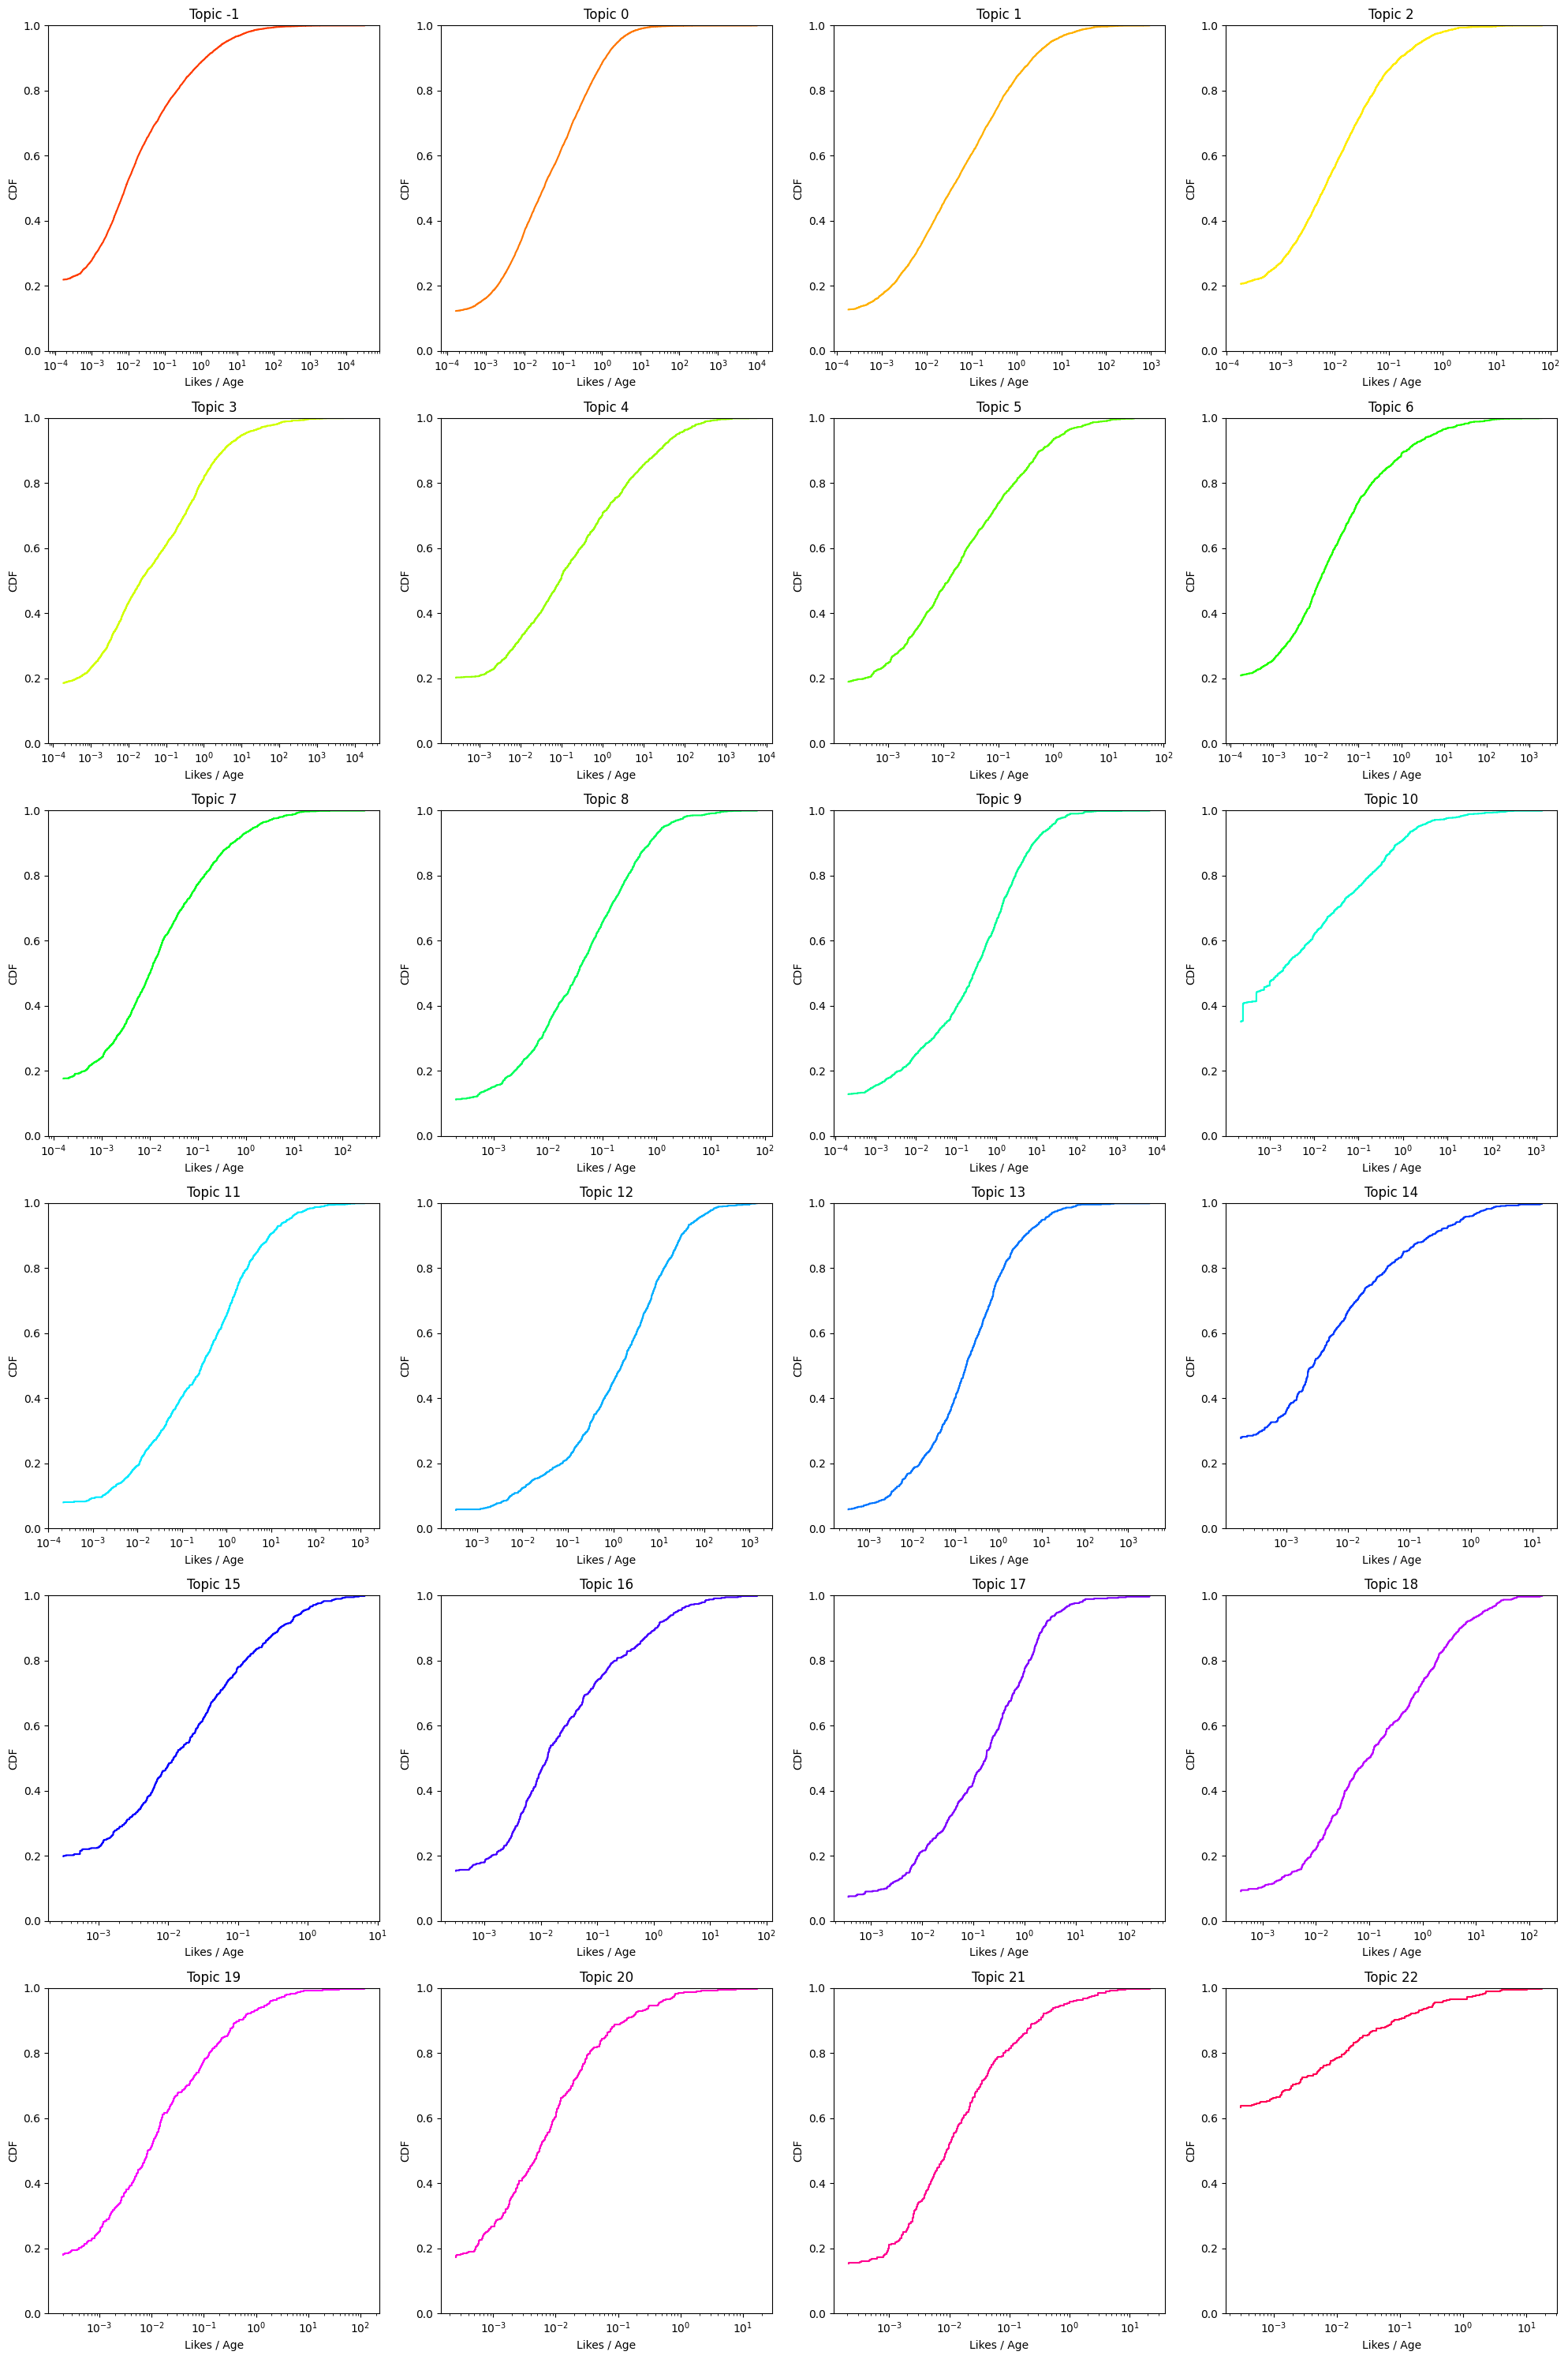

In [41]:
topic_ids = sorted(set(row["topic_id"] for row in result))

cols = 4
rows = math.ceil(len(topic_ids) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, 5*rows))
axes = axes.flatten()

colors = sns.color_palette("hsv", len(topic_ids))

for i, topic_id in enumerate(topic_ids):
    normalized_views = [
        row["likeCount"] / row["age"]
        for row in result
        if row["topic_id"] == topic_id and row["age"] > 0
    ]

    sns.ecdfplot(normalized_views, log_scale=True, ax=axes[i], color=colors[i])

    axes[i].set_title(f"Topic {topic_id}")
    axes[i].set_xlabel("Likes / Age")
    axes[i].set_ylabel("CDF")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()